# Contributions EDA

In [2]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
cand_summ_22 = pd.read_parquet('./datasets/cand_summ_22.parquet', engine="fastparquet")
cand_summ_24 = pd.read_parquet('./datasets/cand_summ_24.parquet', engine="fastparquet")

comm_summ_22 = pd.read_parquet('./datasets/comm_summ_22.parquet', engine="fastparquet")
comm_summ_24 = pd.read_parquet('./datasets/comm_summ_24.parquet', engine="fastparquet")

cc_ie_22 = pd.read_parquet('./datasets/cc_ie_22.parquet', engine="fastparquet")
cc_ie_24 = pd.read_parquet('./datasets/cc_ie_24.parquet', engine="fastparquet")

### Candidates Only
Only keep rows directly associated with a candidate id 

In [154]:
len(cc_ie_22)

751519

In [155]:
cc_ie_22 = cc_ie_22.dropna(subset='CAND_ID')

#### But, Can I count on your support
Are these tranaction in support or opposition to a candidate.
https://www.fec.gov/campaign-finance-data/transaction-type-code-descriptions/

In [156]:
support_codes = {"24E", "24F", "24C", "24H", "24K" ,"24P","24R", "24Z"}
oppose_codes = {"24A", "24N"}

cc_ie_22 = cc_ie_22.copy()
cc_ie_22["support_oppose_flag"] = "N"

cc_ie_22.loc[cc_ie_22["TRANSACTION_TP"].isin(support_codes), "support_oppose_flag"] = "S"

cc_ie_22.loc[cc_ie_22["TRANSACTION_TP"].isin(oppose_codes), "support_oppose_flag"] = "O"

In [157]:
print(len(cc_ie_22[cc_ie_22['support_oppose_flag'] == "N"]))
print(cc_ie_22[cc_ie_22['support_oppose_flag'] == "N"]['TRANSACTION_TP'].unique())
#cc_ie_22[cc_ie_22['support_oppose_flag'] == "N"]

0
[]


Before a correction these was only 23 rows labeled as N, all of which were labeled 24R. THis is the listing for 24R on the FEC website:
"24R	Election recount disbursement"
*For now I fill assume all of these to be in support

#### What the hell is a 24k?
24k - Contribution made to nonaffiliated committee, but why are there so many and what does it mean when they are associated with a candidates

Text(0.5, 1.0, 'Transaction Type')

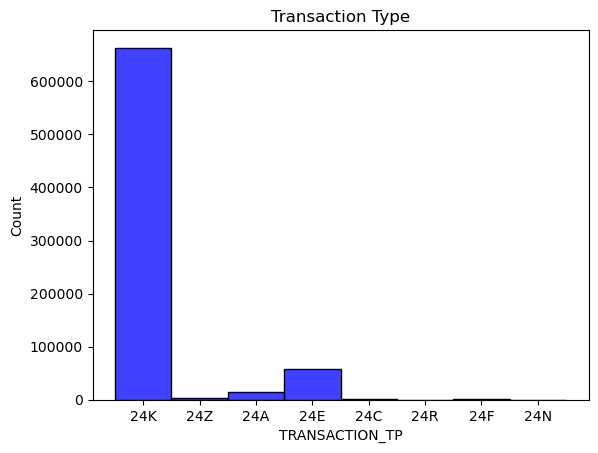

In [201]:
sns.histplot(data=cc_ie_22, x='TRANSACTION_TP', color='blue')
plt.title('Transaction Type')

In [145]:
cc_ie_22[cc_ie_22['TRANSACTION_TP']=='24K'].sample(5)

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
481146,C00694323,N,YE,P2020,202301319576190344,24K,CCM,ZINKE FOR CONGRESS,WHITEFISH,MT,...,2022-12-19,-10.0,C00778159,H4MT01041,AA2064E84BDC54F23B75,1686511,None,None,4021620231727329664,S
482008,C00694323,N,YE,P2020,202301319576191301,24K,CCM,KIRKMEYERFORCONGRESS.COM,FORT LUPTON,CO,...,2022-12-05,-25.0,C00794602,H2CO08079,AB0D6AB111D004A09B23,1686511,None,None,4021620231727332537,S
468537,C00694323,N,YE,P2020,202301319576181314,24K,CCM,THE BILLY PREMPEH FOR CONGRESS COMMITTEE,PATERSON,NJ,...,2022-12-02,-5.0,C00739581,H0NJ09200,A13E33E9574E240ABA4D,1686511,None,None,4021620231727302576,S
50127,C00341602,N,M7,P2026,202107209451766145,24K,CCM,COLLINS FOR SENATOR,BANGOR,ME,...,2021-06-15,1000.0,C00314575,S6ME00159,B62DF33D239F64510BD2,1528969,None,None,4072320211322482915,S
378357,C00109017,N,M7,G2022,202207209522341906,24K,CCM,MATSUI FOR CONGRESS,SACRAMENTO,CA,...,2022-06-14,5000.0,C00409219,H6CA05195,18735751,1618033,None,None,4072920221553577725,S


In [161]:
cand_names = cand_summ_22[['Cand_Id','Cand_Name']].copy()
comm_names = comm_summ_22[['CMTE_ID','CMTE_NM']].copy()
sample =  cc_ie_22[cc_ie_22['TRANSACTION_TP']=='24K'].sample(7)

pd.merge(comm_names, pd.merge(cand_names, sample[['CAND_ID','CMTE_ID','OTHER_ID','NAME']], left_on='Cand_Id', right_on='CAND_ID'), on='CMTE_ID')

,CMTE_ID,CMTE_NM,Cand_Id,Cand_Name,CAND_ID,OTHER_ID,NAME
0,C00113811,NATIONAL ELECTRICAL CONTRACTORS ASSOCIATION PO...,H2MA09072,"LYNCH, STEPHEN",H2MA09072,C00366948,STEPHEN LYNCH FOR CONGRESS
1,C00144766,NATIONAL BEER WHOLESALERS ASSOCIATION POLITICA...,H0WI07101,"TIFFANY, TOM",H0WI07101,C00718635,"TIFFANY FOR WISCONSIN, INC."
2,C00694323,WINRED,H2PA04135,"PERRY, SCOTT",H2PA04135,C00510164,PATRIOTS FOR PERRY
3,C00163048,CAP-PAC SEPARATE SEGREGATED FUND OF THE NATION...,H0NM03102,"LEGER FERNANDEZ, TERESA",H0NM03102,C00704049,TERESA FOR ALL


#### Conclusion: I misinterpted what was meant by 'nonaffliated' (legally not pol) but still found somethign cool

### What's this whole amendment business?

Indicates if the report being filed is new (N), an amendment (A) to a previous report or a termination (T) report.

A committee that wishes to close down its operations can file a termination report when it meets these criteria:

It no longer receives (or intends to receive) contributions; and
It no longer makes (or intends to make) expenditures.
A termination report may be filed anytime and may be combined with a regularly scheduled report. For example, a quarterly report may also serve as a termination report if the filer checks the “Termination Report” box.

In [162]:
cc_ie_22[cc_ie_22['AMNDT_IND'] == 'A'].head(2)

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
32,C00760025,A,TER,G2020,202101079398285521,24A,PAC,MUSLIMS OF UNITED STATES OF AMERICA PAC,LAKEWOOD,CO,...,2021-01-04,29.0,H0VA01235,H0VA01235,SE.4323,1486017,None,None,4011120212068262407,O
612,C00455733,A,M2,P2022,202102119427674409,24K,CCM,BRENDA LAWRENCE FOR CONGRESS,SOUTHFIELD,MI,...,2021-01-13,1000.0,C00552588,H2MI14111,12960166,1499620,None,DIRECT CONTRIBUTION,4022620211189794740,S


In [163]:
#cc_ie_22[cc_ie_22['AMNDT_IND'] == 'A'] #.columns
cc_ie_22[cc_ie_22['TRANSACTION_TP'] == '24A'] #.columns
#cc_ie_22[cc_ie_22['TRAN_ID'] == '12960186']
#comm_summ_22[comm_summ_22['CMTE_ID']=='C00760025']

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
8,C00760454,N,30R,R2021,202101299413959554,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,171.0,S8GA00180,S8GA00180,PDTE3,1493602,X,None,4020320212140454338,O
9,C00760454,N,30R,R2021,202101299413959554,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,171.0,S0GA00559,S0GA00559,PDTE4,1493602,X,None,4020320212140454339,O
10,C00760454,N,30R,R2021,202101299413959555,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,111.0,S8GA00180,S8GA00180,PDTE16,1493602,X,None,4020320212140454340,O
11,C00760454,N,30R,R2021,202101299413959555,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-16,111.0,S0GA00559,S0GA00559,PDTE17,1493602,X,None,4020320212140454341,O
12,C00760454,N,30R,R2021,202101299413959557,24A,ORG,"FIREARMS POLICY COALITION, INC.",SACRAMENTO,CA,...,2020-12-17,56.0,S0GA00559,S0GA00559,PDTE21,1493602,X,None,4020320212140454345,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751390,C00742296,A,Q3,P2022,202307209583904625,24A,ORG,THE STONERIDGE GROUP LLC,ALPHARETTA,GA,...,2022-08-16,1250.0,H2FL15233,H2FL15233,SE.4840,1716397,None,None,4072120231756506143,O
751392,C00742296,A,Q3,P2022,202307209583904619,24A,ORG,DYNAMIC MEDIA STRATEGIES LLC,FALLSTON,MD,...,2022-08-12,56250.0,H2FL15233,H2FL15233,SE.4836,1716397,None,None,4072120231756506130,O
751393,C00742296,A,Q3,P2022,202307209583904619,24A,ORG,DYNAMIC MEDIA STRATEGIES LLC,FALLSTON,MD,...,2022-08-12,10000.0,H2FL15233,H2FL15233,SE.4838,1716397,None,None,4072120231756506131,O
751394,C00742296,A,Q3,P2022,202307209583904620,24A,ORG,DYNAMIC MEDIA STRATEGIES LLC,FALLSTON,MD,...,2022-08-18,60000.0,H2FL15233,H2FL15233,SE.4892,1716397,None,None,4072120231756506132,O


In [12]:
comm_summ_22.columns

Index(['Link_Image', 'CMTE_ID', 'CMTE_NM', 'CMTE_TP', 'CMTE_DSGN',
       'CMTE_FILING_FREQ', 'CMTE_ST1', 'CMTE_ST2', 'CMTE_CITY', 'CMTE_ST',
       'CMTE_ZIP', 'TRES_NM', 'CAND_ID', 'FEC_ELECTION_YR', 'INDV_CONTB',
       'PTY_CMTE_CONTB', 'OTH_CMTE_CONTB', 'TTL_CONTB',
       'TRANF_FROM_OTHER_AUTH_CMTE', 'OFFSETS_TO_OP_EXP', 'OTHER_RECEIPTS',
       'TTL_RECEIPTS', 'TRANF_TO_OTHER_AUTH_CMTE', 'OTH_LOAN_REPYMTS',
       'INDV_REF', 'POL_PTY_CMTE_REF', 'TTL_CONTB_REF', 'OTHER_DISB',
       'TTL_DISB', 'NET_CONTB', 'NET_OP_EXP', 'COH_BOP', 'CVG_START_DT',
       'COH_COP', 'CVG_END_DT', 'DEBTS_OWED_BY_CMTE', 'DEBTS_OWED_TO_CMTE',
       'INDV_ITEM_CONTB', 'INDV_UNITEM_CONTB', 'OTH_LOANS',
       'TRANF_FROM_NONFED_ACCT', 'TRANF_FROM_NONFED_LEVIN', 'TTL_NONFED_TRANF',
       'LOAN_REPYMTS_RECEIVED', 'OFFSETS_TO_FNDRSG', 'OFFSETS_TO_LEGAL_ACCTG',
       'FED_CAND_CONTB_REF', 'TTL_FED_RECEIPTS', 'SHARED_FED_OP_EXP',
       'SHARED_NONFED_OP_EXP', 'OTHER_FED_OP_EXP', 'TTL_OP_EXP',
       '

In [13]:
cand_summ_22[cand_summ_22['Cand_Id']=='H2MI03197']

,Link_Image,Cand_Name,Cand_Id,Cand_Office,Cand_Office_St,Cand_Office_Dist,Cand_Party_Affiliation,Cand_Incumbent_Challenger_Open_Seat,Total_Receipt,Total_Disbursement,...,Individual_Refund,Party_Committee_Refund,Other_Committee_Refund,Total_Contribution_Refund,Other_Disbursements,Net_Contribution,Net_Operating_Expenditure,Cash_On_Hand_BOP,Debt_Owe_To_Committee,Coverage_Start_Date
4360,https://www.fec.gov/data/candidate/H2MI03197/?...,"GIBBS, JOHN",H2MI03197,H,MI,3.0,REP,CHALLENGER,1686030.12,1684742.38,...,875.0,0.0,1420.26,2295.26,0.0,950535.86,1058479.89,0.0,0.0,11/15/2021


In [14]:
comm_summ_22[comm_summ_22['CMTE_ID']=='C00794040']

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
11877,https://www.fec.gov/data/committee/C00794040/?...,C00794040,GILBERT VILLEGAS FOR CONGRESS,H,P,Q,6560 W FULLERTON AVE,UNIT # C118 - SUITE B,CHICAGO,IL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


Text(0.5, 1.0, 'Amendment Indicator of Report')

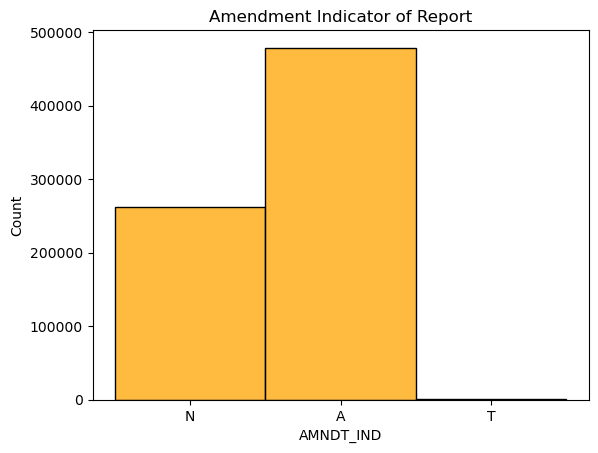

In [202]:
sns.histplot(data=cc_ie_22, x='AMNDT_IND', color='orange')
plt.title('Amendment Indicator of Report')

Note on TRAN_ID: "ONLY VALID FOR ELECTRONIC FILINGS. A unique identifier associated with each itemization or transaction appearing in an FEC electronic file. A transaction ID is unique for a specific committee for a specific report. In other words, if committee, C1, files a Q3 New with transaction SA123 and then files 3 amendments to the Q3 transaction SA123 will be identified by transaction ID SA123 in all 4 filings."

However some 'A' rows do not have a corresponding 'N' it is not immediately clear why this is but it can be assumed based on the FEC quote above that if we just take the most recent TRAN_ID in the table

In [164]:
cc_ie_22 = cc_ie_22.sort_values(["CMTE_ID", "TRAN_ID", "FILE_NUM"])
cc_ie_22 = cc_ie_22.groupby(["CMTE_ID", "TRAN_ID"], as_index=False).last().copy()

In [17]:
len(cc_ie_22)

740828

### Should we actually do EDA?

In [188]:
# Define the mapping from states to regions
state_to_region = {
    # New England
    'CT': 'New England', 'ME': 'New England', 'MA': 'New England',
    'NH': 'New England', 'RI': 'New England', 'VT': 'New England',

    # Middle Atlantic
    'NJ': 'Middle Atlantic', 'NY': 'Middle Atlantic', 'PA': 'Middle Atlantic',

    # East North Central
    'IL': 'East North Central', 'IN': 'East North Central', 'MI': 'East North Central',
    'OH': 'East North Central', 'WI': 'East North Central',

    # West North Central
    'IA': 'West North Central', 'KS': 'West North Central', 'MN': 'West North Central',
    'MO': 'West North Central', 'NE': 'West North Central',
    'ND': 'West North Central', 'SD': 'West North Central',

    # South Atlantic
    'DE': 'South Atlantic', 'DC': 'South Atlantic', 'FL': 'South Atlantic',
    'GA': 'South Atlantic', 'MD': 'South Atlantic', 'NC': 'South Atlantic',
    'SC': 'South Atlantic', 'VA': 'South Atlantic', 'WV': 'South Atlantic',

    # East South Central
    'AL': 'East South Central', 'KY': 'East South Central',
    'MS': 'East South Central', 'TN': 'East South Central',

    # West South Central
    'AR': 'West South Central', 'LA': 'West South Central',
    'OK': 'West South Central', 'TX': 'West South Central',

    # Mountain
    'AZ': 'Mountain', 'CO': 'Mountain', 'ID': 'Mountain',
    'MT': 'Mountain', 'NV': 'Mountain', 'NM': 'Mountain',
    'UT': 'Mountain', 'WY': 'Mountain',

    # Pacific
    'AK': 'Pacific', 'CA': 'Pacific', 'HI': 'Pacific',
    'OR': 'Pacific', 'WA': 'Pacific'
}

# Assume your DataFrame is called df
cand_summ_22['Cand_Region'] = cand_summ_22['Cand_Office_St'].map(state_to_region)

In [19]:
cc_ie_22.columns

Index(['CMTE_ID', 'TRAN_ID', 'AMNDT_IND', 'RPT_TP', 'TRANSACTION_PGI',
       'IMAGE_NUM', 'TRANSACTION_TP', 'ENTITY_TP', 'NAME', 'CITY', 'STATE',
       'ZIP_CODE', 'EMPLOYER', 'OCCUPATION', 'TRANSACTION_DT',
       'TRANSACTION_AMT', 'OTHER_ID', 'CAND_ID', 'FILE_NUM', 'MEMO_CD',
       'MEMO_TEXT', 'SUB_ID', 'support_oppose_flag'],
      dtype='object')

In [21]:
len(cc_ie_22[cc_ie_22['TRANSACTION_AMT'] < 0])

263800

In [51]:
contrib_totals = cc_ie_22.groupby(['CMTE_ID','CAND_ID'])['TRANSACTION_AMT'].sum().reset_index().copy()

In [23]:
contrib_totals[contrib_totals['TRANSACTION_AMT'] < 0]

,CMTE_ID,OTHER_ID,CAND_ID,TRANSACTION_AMT
642,C00000885,C00633982,H8CA48035,-1000.0
676,C00000885,C00666453,H8NY27176,-2500.0
683,C00000885,C00675884,S8MS00287,-4000.0
776,C00000901,C00344697,H0RI02139,-3000.0
789,C00000901,C00376665,H2TN05131,-1000.0
...,...,...,...,...
137089,C00777458,C00791293,H2TX03290,-500.0
139864,C00809756,C00701003,H0TX07170,-2100.0
139865,C00809756,C00706267,H0IA01174,-2100.0
139875,C00809756,C00782797,H2IN01172,-2100.0


In [131]:
comm_summ_22[comm_summ_22['CMTE_ID']=='C00706267']

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
11234,https://www.fec.gov/data/committee/C00706267/?...,C00706267,ASHLEY HINSON FOR CONGRESS,H,P,Q,PO BOX 811,None,MARION,IA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


C:\Users\wkmp2\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\wkmp2\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Log Transfromed Transaction Amount Distribution')

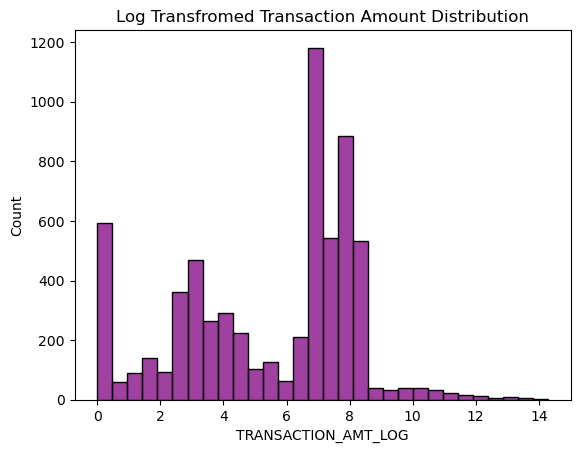

In [203]:
cc_ie_22['TRANSACTION_AMT_LOG'] = np.log1p(cc_ie_22['TRANSACTION_AMT'])

sns.histplot(data=cc_ie_22.sample(10000), x='TRANSACTION_AMT_LOG', color='purple')
plt.title("Log Transfromed Transaction Amount Distribution")

C:\Users\wkmp2\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Total Amount Given by Committee')

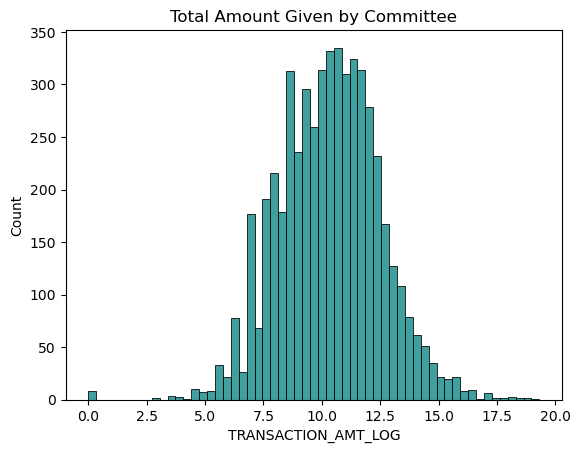

In [205]:
contrib_totals = cc_ie_22[['CMTE_ID','TRANSACTION_AMT']].groupby('CMTE_ID').sum()
contrib_totals ['TRANSACTION_AMT_LOG'] = np.log1p(contrib_totals['TRANSACTION_AMT'])

sns.histplot(data=contrib_totals, x='TRANSACTION_AMT_LOG', color='teal')
plt.title("Total Amount Given by Committee")

In [102]:
contrib_totals['TRANSACTION_AMT'].max()

54905733.0

Text(0.5, 1.0, 'Expenditures and Contributions Over 2022 Election Cycle')

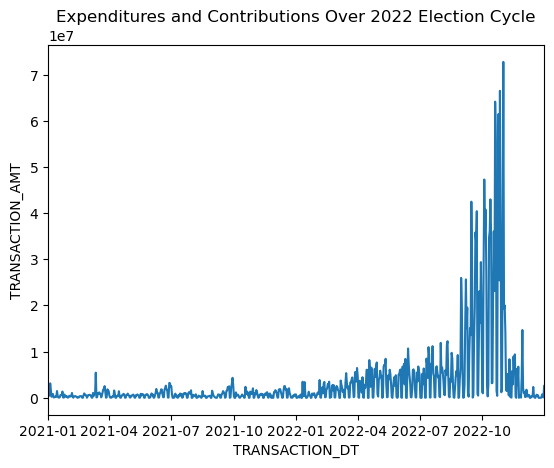

In [206]:
cc_ie_22['TRANSACTION_DT'] = pd.to_datetime(cc_ie_22['TRANSACTION_DT'])
daily = cc_ie_22[['TRANSACTION_DT','TRANSACTION_AMT']].groupby('TRANSACTION_DT').sum()

sns.lineplot(data=daily, x='TRANSACTION_DT', y='TRANSACTION_AMT')
plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'))
plt.title('Expenditures and Contributions Over 2022 Election Cycle')

C:\Users\wkmp2\AppData\Local\Temp\ipykernel_15588\980168714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=w_can_info, x='Cand_Party_Affiliation', y='TRANSACTION_AMT', palette=['blue','purple','red'])


Text(0.5, 1.0, 'Total Support Recieved By Party During 2022 Election Cycle')

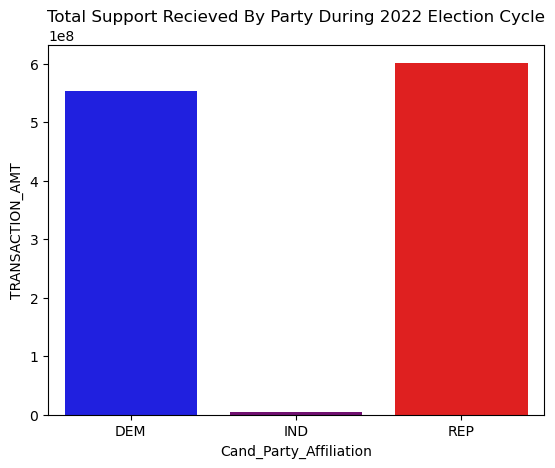

In [195]:
w_can_info = pd.merge(cand_summ_22, cc_ie_22, left_on='Cand_Id', right_on='CAND_ID')

w_can_info = w_can_info[(w_can_info['support_oppose_flag'] != 'O') & ( (w_can_info['Cand_Party_Affiliation'] == 'DEM') | (w_can_info['Cand_Party_Affiliation'] == 'REP') | (w_can_info['Cand_Party_Affiliation'] == 'IND'))].copy()

w_can_info = w_can_info[['Cand_Party_Affiliation','TRANSACTION_AMT']].groupby('Cand_Party_Affiliation').sum()

sns.barplot(data=w_can_info, x='Cand_Party_Affiliation', y='TRANSACTION_AMT', palette=['blue','purple','red'])
plt.title('Total Support Recieved By Party During 2022 Election Cycle')

### This is such a Cluster f-

In [30]:
interaction_matrix = (
    cc_ie_22.pivot_table(
        index="CAND_ID",          # rows
        columns="CMTE_ID",        # columns
        values="TRANSACTION_AMT", # cell values
        aggfunc="sum",            # sum of transactions
        fill_value=0              # replace NaNs with 0
    )
)

In [31]:
interaction_matrix

CMTE_ID,C00000059,C00000422,C00000729,C00000885,C00000901,C00000935,C00000984,C00001016,C00001198,C00001214,...,C90021866,C90021882,C90021890,C90021924,C90021932,C90021965,C90021973,C90021981,C90021999,C90022005
CAND_ID,,,,,,,,,,,,,,,,,,,,,
H0AL01055,0.0,0.0,1000.0,0.0,5500.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL02087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL02202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL05163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL07086,0.0,5000.0,3500.0,0.0,3500.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S8TX00285,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S8UT00176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S8WA00194,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
interaction_matrix.max().max()

54905733.0

In [68]:
interaction_matrix.max(axis=1).idxmax()

'S2GA00225'

In [70]:
interaction_matrix.loc['S2GA00225'].idxmax(axis=0)

'C00763193'

In [54]:
contrib_totals['TRANSACTION_AMT'].max()

54905733.0

In [74]:
comm_summ_22[comm_summ_22['CMTE_ID'] == 'C00763193']

,Link_Image,CMTE_ID,CMTE_NM,CMTE_TP,CMTE_DSGN,CMTE_FILING_FREQ,CMTE_ST1,CMTE_ST2,CMTE_CITY,CMTE_ST,...,ITEM_CONVN_EXP_DISB,ITEM_OTHER_DISB,SUBTTL_CONVN_EXP_DISB,TTL_EXP_SUBJECT_LIMITS,UNITEM_CONVN_EXP_DISB,UNITEM_OTHER_DISB,TTL_COMMUNICATION_COST,COH_BOY,COH_COY,ORG_TP
4839,https://www.fec.gov/data/committee/C00763193/?...,C00763193,GEORGIA HONOR,O,U,M,1032 15TH STREET NW,SUITE 247,WASHINGTON,DC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [72]:
cc_ie_22[(cc_ie_22['CMTE_ID'] == 'C00763193') & (cc_ie_22['CAND_ID'] == 'S2GA00225')]

,CMTE_ID,TRAN_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,...,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,CAND_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,support_oppose_flag
707778,C00763193,500147237,N,M9,G2022,202209209531790422,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-26,14323.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784907,O
707779,C00763193,500147238,N,M9,G2022,202209209531790421,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-01,1138258.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784905,O
707780,C00763193,500147239,N,M9,G2022,202209209531790421,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-01,450275.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784906,O
707781,C00763193,500147245,N,M9,G2022,202209209531790425,24A,ORG,WATERFRONT STRATEGIES,WASHINGTON,...,None,2022-08-01,1559886.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784913,O
707782,C00763193,500147249,N,M9,G2022,202209209531790422,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-08-26,3041.0,S2GA00225,S2GA00225,1631893,None,None,4092320221576784908,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707875,C00763193,500154309,N,YE,R2022,202301319576517621,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-11-29,428400.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599552,O
707880,C00763193,500154331,N,YE,R2022,202301319576517624,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-12-12,13558.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599558,O
707881,C00763193,500154332,N,YE,R2022,202301319576517625,24A,ORG,"MVAR MEDIA, LLC",ALEXANDRIA,...,None,2022-12-12,2844.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599559,O
707882,C00763193,500154333,N,YE,R2022,202301319576517628,24A,ORG,WATERFRONT STRATEGIES,WASHINGTON,...,None,2022-11-29,377595.0,S2GA00225,S2GA00225,1686587,None,None,4020820231723599566,O


In [132]:
cc_ie_22[cc_ie_22['CAND_ID'] == 'S2GA00225'].columns

Index(['CMTE_ID', 'AMNDT_IND', 'RPT_TP', 'TRANSACTION_PGI', 'IMAGE_NUM',
       'TRANSACTION_TP', 'ENTITY_TP', 'NAME', 'CITY', 'STATE', 'ZIP_CODE',
       'EMPLOYER', 'OCCUPATION', 'TRANSACTION_DT', 'TRANSACTION_AMT',
       'OTHER_ID', 'CAND_ID', 'TRAN_ID', 'FILE_NUM', 'MEMO_CD', 'MEMO_TEXT',
       'SUB_ID'],
      dtype='object')

C:\Users\wkmp2\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\wkmp2\AppData\Local\Temp\ipykernel_15588\434116666.py:29: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

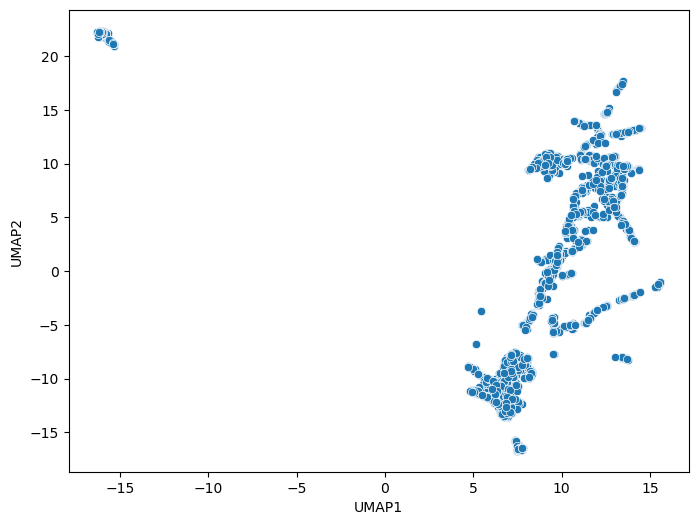

In [103]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# pivot table creation, and feature engineering!!

scaler = StandardScaler()

#30 #20
svd = TruncatedSVD(n_components=15, random_state=56)
latent = svd.fit_transform(interaction_matrix)
scaler_latent = scaler.fit_transform(latent)

scaled_latent_df = pd.DataFrame(
    scaler_latent,
    index=interaction_matrix.index,
    columns=[f"latent_{i+1}" for i in range(scaler_latent.shape[1])]
)

reducer = umap.UMAP(random_state=26)
embedding = reducer.fit_transform(scaled_latent_df)

embeddings_df = pd.DataFrame(embedding, index= scaled_latent_df.index, columns=["UMAP1","UMAP2"])
#embeddings_with_clusters = pd.merge(cluster_labels, embeddings_df, left_index=True, right_index=True)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=embeddings_df,
    x="UMAP1",y="UMAP2",
    palette='mako'
)

In [113]:
interaction_matrix

CMTE_ID,C00000059,C00000422,C00000729,C00000885,C00000901,C00000935,C00000984,C00001016,C00001198,C00001214,...,C90021866,C90021882,C90021890,C90021924,C90021932,C90021965,C90021973,C90021981,C90021999,C90022005
CAND_ID,,,,,,,,,,,,,,,,,,,,,
H0AL01055,0.0,0.0,1000.0,0.0,5500.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL02087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL02202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL05163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H0AL07086,0.0,5000.0,3500.0,0.0,3500.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S8TX00285,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S8UT00176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
S8WA00194,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [121]:
contrib_totals[contrib_totals['CAND_ID']=='H2CA01185']

,CMTE_ID,CAND_ID,TRANSACTION_AMT


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

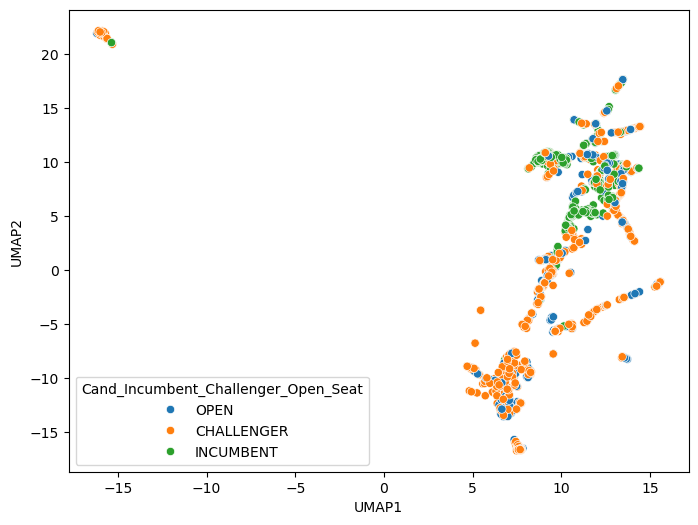

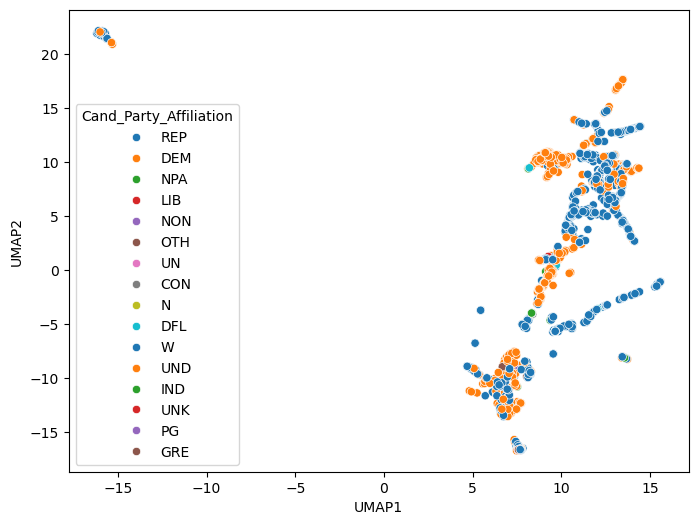

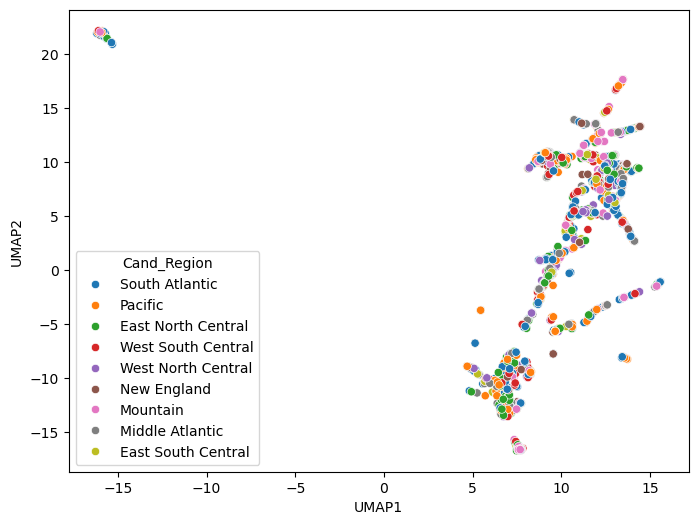

In [111]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Cand_Incumbent_Challenger_Open_Seat'
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Cand_Party_Affiliation'
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Cand_Region'
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pd.merge(cand_summ_22, embeddings_df, left_on='Cand_Id', right_on='CAND_ID'),
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='Net_Contribution'
)

In [82]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import HDBSCAN
from sklearn.cluster import AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

#dbscan = DBSCAN(eps= 0.1, min_samples = 10)
#clusters = dbscan.fit_predict(scaled_latent_df)

"""
for eps in [0.1, 0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    clusters = dbscan.fit_predict(scaled_latent_df)
    print(f"eps={eps}: {len(set(clusters)) - (1 if -1 in clusters else 0)} clusters, {sum(clusters == -1)} noise points")
"""

hdbscan = HDBSCAN(min_cluster_size= 50, min_samples = 2)
clusters = hdbscan.fit_predict(scaled_latent_df)

#kmeans = KMeans(n_clusters=6, random_state=65)
#clusters = kmeans.fit_predict(scaled_latent_df)

#ap = AffinityPropagation(damping = 0.9, preference = -50)
#clusters = ap.fit_predict(scaled_latent_df)

#gmm = GaussianMixture(n_components=8,covariance_type='full',random_state=56)
#clusters = gmm.fit_predict(scaled_latent_df)

"""results = []

for n in range(2,11):
    gmm = GaussianMixture(n_components=n,covariance_type='full',random_state=56)
    clusters = gmm.fit_predict(scaled_latent_df)

    score = silhouette_score(scaled_latent_df,clusters)
    results.append({'n_clusters': n, 'silhoutte_score':score})

silt_df = pd.DataFrame(results)"""

cluster_labels = pd.DataFrame(clusters, index=scaled_latent_df.index,columns=['cluster'])

C:\Users\wkmp2\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

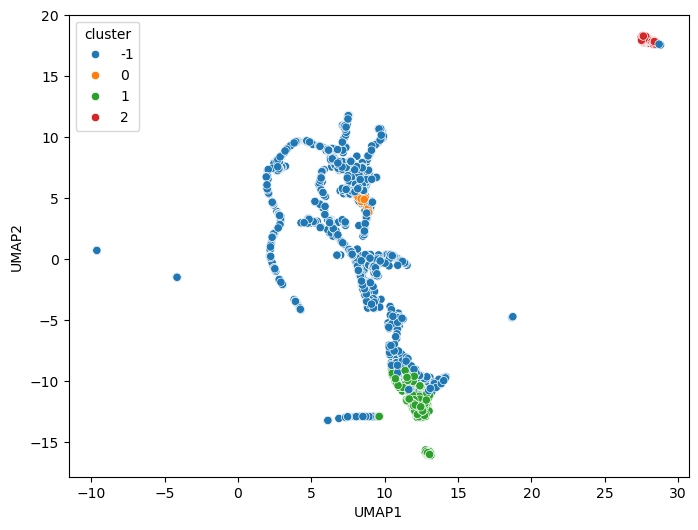

In [83]:
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=26)
embedding = reducer.fit_transform(scaled_latent_df)

embeddings_df = pd.DataFrame(embedding, index= scaled_latent_df.index, columns=["UMAP1","UMAP2"])
embeddings_with_clusters = pd.merge(cluster_labels, embeddings_df, left_index=True, right_index=True)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=embeddings_with_clusters,
    x="UMAP1",y="UMAP2",
    palette = "tab10",
    hue='cluster'
)

<Axes: xlabel='Cand_Incumbent_Challenger_Open_Seat', ylabel='Count'>

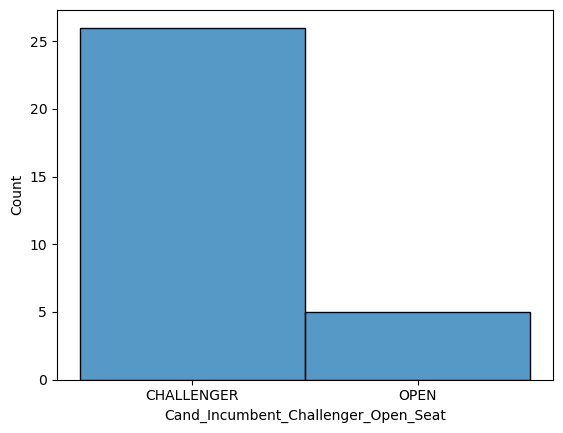

In [101]:
sns.histplot(pd.merge(cand_summ_22, cluster_labels[cluster_labels['cluster'] == 2], left_on='Cand_Id', right_on='CAND_ID'), x='Cand_Incumbent_Challenger_Open_Seat')

In [110]:
pd.merge(cand_summ_22, cluster_labels[cluster_labels['cluster'] == 1], left_on='Cand_Id', right_on='CAND_ID').columns

Index(['Link_Image', 'Cand_Name', 'Cand_Id', 'Cand_Office', 'Cand_Office_St',
       'Cand_Office_Dist', 'Cand_Party_Affiliation',
       'Cand_Incumbent_Challenger_Open_Seat', 'Total_Receipt',
       'Total_Disbursement', 'Cash_On_Hand_COP', 'Debt_Owed_By_Committee',
       'Coverage_End_Date', 'Cand_Street_1', 'Cand_Street_2', 'Cand_City',
       'Cand_State', 'Cand_Zip', 'Individual_Itemized_Contribution',
       'Individual_Unitemized_Contribution', 'Individual_Contribution',
       'Other_Committee_Contribution', 'Party_Committee_Contribution',
       'Cand_Contribution', 'Total_Contribution',
       'Transfer_From_Other_Auth_Committee', 'Cand_Loan', 'Other_Loan',
       'Total_Loan', 'Offsets_To_Operating_Expenditure',
       'Offsets_To_Fundraising', 'Offsets_To_Leagal_Accounting',
       'Other_Receipts', 'Operating_Expenditure',
       'Exempt_Legal_Accounting_Disbursement', 'Fundraising_Disbursement',
       'Transfer_To_Other_Auth_Committee', 'Cand_Loan_Repayment',
       'O

In [91]:
cluster_labels[cluster_labels['cluster'] == 1]

,cluster
CAND_ID,
H0AL02087,1
H0AL02202,1
H0CA18068,1
H0CA22110,1
H0CA28174,1
...,...
S8MN00586,1
S8MN00628,1
S8TX00285,1
